# Interpretation & Fazit (Projektteil 1: Mieten in NRW)

Dieses Notebook fasst die Ergebnisse aus den vorherigen Notebooks zusammen:

- 01_obtain.ipynb (Daten laden + NRW-Filter)
- 02_scrub.ipynb (Bereinigung + Feature Engineering + Export `nrw_clean.csv`)
- 03_explore.ipynb (Deskriptive Analyse / Visualisierung)
- 04_model_hypothesis_testing.ipynb (Hypothesentests + Clustering)

Datengrundlage: `data/processed/nrw_clean.csv`


## Forschungsfragen (Projektteil 1)

1. **Wie unterscheiden sich die Mietpreise pro Quadratmeter zwischen den Städten in NRW?**
2. **Sind kleinere Wohnungen pro Quadratmeter teurer als größere Wohnungen?**
3. **Haben Wohnungsmerkmale (z. B. Balkon, Küche, Baujahr) einen messbaren Einfluss auf die Mietpreise?**
4. **Lassen sich Mietangebote in NRW mithilfe von Datenanalyse-Methoden in unterschiedliche Muster gruppieren?**


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from scipy.stats import mannwhitneyu, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

path_clean = Path("../../data/processed/nrw_clean.csv")
df = pd.read_csv(path_clean)

df.shape, df.columns


C:\Users\User\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


((62822, 9),
 Index(['regio2', 'baseRent', 'totalRent', 'livingSpace', 'noRooms', 'balcony',
        'hasKitchen', 'yearConstructed', 'price_per_sqm'],
       dtype='object'))

In [2]:
df.isna().sum()


regio2                 0
baseRent               0
totalRent          12091
livingSpace            0
noRooms                0
balcony                0
hasKitchen             0
yearConstructed    12037
price_per_sqm          0
dtype: int64

## RQ1 – Städtevergleich (€/m²)

**Frage:** Wie unterscheiden sich die Mietpreise pro Quadratmeter zwischen den Städten in NRW?

Vorgehen (wie in Explore):
- Fokus auf Städte mit vielen Angeboten (Top-10 nach Anzahl Inserate)
- Vergleich über **Median €/m²**, da Preisverteilungen oft schief sind (robuster als Mittelwert)


In [3]:
top_cities = df["regio2"].value_counts().head(10).index

rq1_table = (
    df[df["regio2"].isin(top_cities)]
    .groupby("regio2")["price_per_sqm"]
    .agg(median="median", n="size")
    .sort_values("median", ascending=False)
)

rq1_table


,median,n
regio2,,
Köln,12.567444,2702
Düsseldorf,11.988548,3708
Aachen,9.420290,1889
Dortmund,7.707160,3135
Essen,7.222368,4350
Bochum,7.142857,2007
Wuppertal,6.500000,2376
Recklinghausen_Kreis,6.168831,2754
Duisburg,6.020558,3519


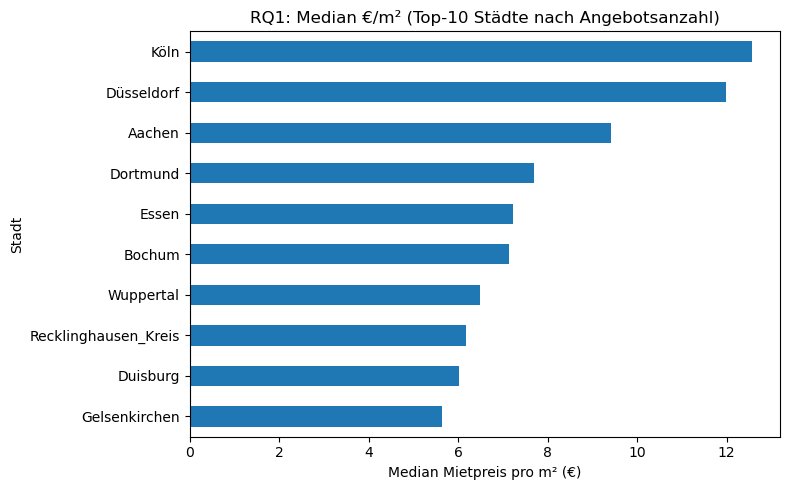

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
rq1_table["median"].sort_values().plot(kind="barh")
plt.xlabel("Median Mietpreis pro m² (€)")
plt.ylabel("Stadt")
plt.title("RQ1: Median €/m² (Top-10 Städte nach Angebotsanzahl)")
plt.tight_layout()
plt.show()


**Interpretation (RQ1):**  
Die Median-Mietpreise pro Quadratmeter unterscheiden sich deutlich zwischen Städten in NRW.
Die teuersten Städte innerhalb der Top-10 liegen spürbar über den günstigsten.
Dies deutet auf starke regionale Unterschiede im Wohnungsmarkt hin (z. B. Nachfrage, Arbeitsmarkt, Lagefaktoren).

Als "teure" Städte gelten demnach: Köln und Düsseldorf. <br>
Günstige Städte sind beispielsweise: Duisburg und Gelsenkirchen.


## RQ2 – Wohnungsgröße (klein vs. groß)

**Frage:** Sind kleinere Wohnungen pro Quadratmeter teurer als größere Wohnungen?

Vorgehen (wie in Model):
- kleine Wohnungen: `< 50 m²`
- große Wohnungen: `> 80 m²`
- Vergleich der €/m²-Verteilungen mit **Mann-Whitney-U** (nicht-parametrisch)
- Hypothese (einseitig): kleine Wohnungen sind teurer pro m²


In [5]:
small = df[df["livingSpace"] < 50]["price_per_sqm"]
large = df[df["livingSpace"] > 80]["price_per_sqm"]

small.median(), large.median(), len(small), len(large)


(8.2389289392379, 7.960631060935012, 9193, 19805)

In [6]:
u_stat, p_value = mannwhitneyu(small, large, alternative="greater")
u_stat, p_value


(101956357.5, 3.162664068632506e-61)

**Interpretation (RQ2):**  
Der Mann-Whitney-U-Test prüft, ob die Verteilung von €/m² bei kleinen Wohnungen systematisch höher ist als bei großen.
Ist `p < 0.05`, wird die Nullhypothese verworfen <br>  > kleine Wohnungen sind statistisch signifikant teurer pro m².


## RQ3 – Einfluss von Wohnungsmerkmalen

**Frage:** Haben Wohnungsmerkmale (z. B. Balkon, Küche, Baujahr) einen messbaren Einfluss auf die Mietpreise?

Vorgehen (wie in 04_Model):
- Balkon: Mann-Whitney-U (einseitig: mit Balkon teurer)
- Küche: Mann-Whitney-U (einseitig: mit Küche teurer)
- Baujahr: Spearman-Korrelation (robust, da nicht normalverteilt + fehlende Werte)


In [7]:
with_balcony = df[df["balcony"] == True]["price_per_sqm"]
without_balcony = df[df["balcony"] == False]["price_per_sqm"]

with_balcony.median(), without_balcony.median(), len(with_balcony), len(without_balcony)


(7.575757575757576, 6.690070422535212, 38504, 24318)

In [8]:
u_bal, p_bal = mannwhitneyu(with_balcony, without_balcony, alternative="greater")
u_bal, p_bal


(561094873.5, 0.0)

In [9]:
with_kitchen = df[df["hasKitchen"] == True]["price_per_sqm"]
without_kitchen = df[df["hasKitchen"] == False]["price_per_sqm"]

with_kitchen.median(), without_kitchen.median(), len(with_kitchen), len(without_kitchen)


(9.002183211851353, 6.875, 13480, 49342)

In [10]:
u_k, p_k = mannwhitneyu(with_kitchen, without_kitchen, alternative="greater")
u_k, p_k


(481650744.5, 0.0)

In [11]:
tmp = df[["yearConstructed", "price_per_sqm"]].dropna()

rho, p_year = spearmanr(tmp["yearConstructed"], tmp["price_per_sqm"])
rho, p_year, tmp.shape


(0.30322604278165116, 0.0, (50785, 2))

**Interpretation (RQ3):**  
- **Balkon:** Wenn `p < 0.05`, sind Wohnungen mit Balkon signifikant teurer pro m².  
- **Küche:** Wenn `p < 0.05`, sind Wohnungen mit Einbauküche signifikant teurer pro m².  
- **Baujahr:** Spearman zeigt Richtung und Stärke des Zusammenhangs zwischen Baujahr und €/m² (kein Kausalbeweis).

Insgesamt legen die Tests nahe, dass Ausstattungsmerkmale messbar mit höheren €/m² zusammenhängen.


## RQ4 – Muster/Cluster in Mietangeboten

**Frage:** Lassen sich Mietangebote in NRW mithilfe von Datenanalyse-Methoden in unterschiedliche Muster gruppieren?

Vorgehen (wie in Model):
- Features (wie in 04): `livingSpace`, `noRooms`, `balcony`, `hasKitchen`, `yearConstructed`
- Standardisierung (StandardScaler)
- Clustering mit KMeans (k=3)
- Interpretation über Cluster-Profile (Mittelwerte der Merkmale je Cluster)


**Interpretation (RQ4):**  
Die Cluster zeigen unterschiedliche „Typen“ von Mietangeboten, die sich durch Größe, Zimmerzahl,
Ausstattung und Baujahr unterscheiden. Das spricht dafür, dass der Markt aus mehreren
charakteristischen Angebotsmustern besteht (z. B. kleinere/ältere Wohnungen vs. größere/neue Wohnungen).


## Limitationen
- Es handelt sich um Angebotsmieten (nicht zwingend Vertragsmieten).
- Einige Variablen enthalten fehlende Werte (z. B. Baujahr, Gesamtmiete).
- Wichtige Preistreiber fehlen (Mikrolage, Modernisierung, Energieeffizienz, Nachfrage, Einkommen).
- Hypothesentests zeigen statistische Unterschiede/Zusammenhänge, aber keine Kausalität.

## Fazit
Die Analyse zeigt klare Unterschiede der Mietpreise zwischen NRW-Städten.
Kleinere Wohnungen sind pro Quadratmeter teurer als größere, und Merkmale wie Balkon oder Küche
gehen messbar mit höheren €/m² einher. Zusätzlich lassen sich Mietangebote mithilfe von Clustering
in unterschiedliche Muster gruppieren.
